# Decision-Maker Agentic RAG with Self-Correction

**Decision-Maker RAG** incorporates dynamic tool selection, document relevance grading, and self-correcting query reformulation.

### Architecture Flow:
1. **Agent Router**: An LLM agent selects the appropriate domain retriever (`LangGraph Blog` vs `LangChain Tutorials`) or replies directly.
2. **Dynamic Tool Execution**: Executes the selected retriever tool.
3. **Relevance Grader (`grade_documents`)**: Evaluates retrieved chunks for relevance to the question.
   - **Relevant** $\rightarrow$ Routes to `generate` to produce the final answer.
   - **Irrelevant** $\rightarrow$ Routes to `rewrite` to reformulate the query and loops back to the agent!

## Workflow Architecture

<div align="center">
  <img src="workflow_decision_maker_rag.png" alt="Decision-Maker RAG Architecture Diagram" width="550" />
</div>

<details>
<summary><b>Click to expand Colorful Mermaid Source Code</b></summary>

```mermaid
flowchart TD
    Start(["1. User Question"]):::startNode
    
    subgraph AgentCore["Agent Reasoning & Router"]
        Agent["2. agent Node<br/><b>Groq LLM + Tool Binding</b><br/>(Selects Retriever or Direct Answer)"]:::agentNode
        AgentDecision{"tools_condition<br/>Tool Call Generated?"}:::decideNode
    end
    
    subgraph MultiRetriever["Specialized Retrievers (FAISS + MiniLM)"]
        Retriever["3. retrieve (ToolNode)<br/><b>LangGraph Blog OR LangChain Blog</b><br/>(Dynamic Tool Selection)"]:::retNode
    end
    
    subgraph SelfCorrection["Self-Correction & Evaluation"]
        Grader{"grade_documents<br/>Relevant to Question?"}:::gradeNode
        Rewrite["4. rewrite Node<br/><b>Question Reformulation</b><br/>(Semantic Query Transformation)"]:::rewriteNode
        Generate["5. generate Node<br/><b>Grounded Answer Synthesis</b><br/>(Contextual QA LLM)"]:::genNode
    end
    
    EndNode(["6. Final Answer"]):::endNode

    Start --> Agent
    Agent --> AgentDecision
    
    AgentDecision -->|No Tool Call: Direct Reply| EndNode
    AgentDecision -->|Tool Call: Retrieve| Retriever
    
    Retriever --> Grader
    Grader -->|Relevant: 'generate'| Generate
    Grader -->|Not Relevant: 'rewrite'| Rewrite
    
    Rewrite --> Agent
    Generate --> EndNode

    classDef startNode fill:#E8F5E9,stroke:#2E7D32,stroke-width:2px,color:#1B5E20;
    classDef agentNode fill:#E3F2FD,stroke:#1565C0,stroke-width:2px,color:#0D47A1;
    classDef decideNode fill:#FCE4EC,stroke:#C2185B,stroke-width:2px,color:#880E4F;
    classDef retNode fill:#FFF3E0,stroke:#EF6C00,stroke-width:2px,color:#BF360C;
    classDef gradeNode fill:#FFF8E1,stroke:#FFA000,stroke-width:2px,color:#E65100;
    classDef rewriteNode fill:#E0F7FA,stroke:#00838F,stroke-width:2px,color:#004D40;
    classDef genNode fill:#F3E5F5,stroke:#7B1FA2,stroke-width:2px,color:#4A148C;
    classDef endNode fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#B71C1C;
```
</details>

### Key Highlights
- **Multi-Domain Routing**: Chooses between LangGraph blog and LangChain documentation tools based on query intent.
- **Self-Correction Loop**: Irrelevant documents are discarded and the query is automatically transformed to retry retrieval.


## Step 0: Environment Setup

Load environment variables and initialize the **Groq LLM** (`openai/gpt-oss-120b`).


In [1]:
import os
import sys
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
os.environ['USER_AGENT'] = os.getenv('USER_AGENT', 'DecisionMakerRAG/1.0')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

llm = init_chat_model('groq:openai/gpt-oss-120b')
print('Groq LLM initialized successfully.')
llm


Groq LLM initialized successfully.


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002642A7BDE80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002642A7BE900>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

## Step 1: Ingest Domain 1 – LangGraph Documentation

We ingest articles on LangGraph and index them using `sentence-transformers/all-MiniLM-L6-v2`.


In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import create_retriever_tool

embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

# Ingest LangGraph blog
urls_langgraph = ['https://lilianweng.github.io/posts/2023-06-23-agent/']
docs_lg = [WebBaseLoader(u).load() for u in urls_langgraph]
docs_list_lg = [item for sub in docs_lg for item in sub]
splits_lg = text_splitter.split_documents(docs_list_lg)

vs_langgraph = FAISS.from_documents(splits_lg, embeddings)
retriever_langgraph = vs_langgraph.as_retriever()

retriever_tool_langgraph = create_retriever_tool(
    retriever_langgraph,
    'retriever_vector_db_blog',
    'Search and return authoritative information about autonomous agents and LangGraph.',
)
print(f'Retriever tool 1 created: {retriever_tool_langgraph.name}')


C:\Users\itsar\AppData\Local\Temp\ipykernel_8072\2458926929.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader


C:\RAG\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4948.89it/s]

Retriever tool 1 created: retriever_vector_db_blog


## Step 2: Ingest Domain 2 – LangChain Tutorials

We ingest LangChain tutorials and build a second specialized retriever tool.


In [3]:
urls_langchain = [
    'https://python.langchain.com/docs/tutorials/',
    'https://python.langchain.com/docs/tutorials/chatbot/',
    'https://python.langchain.com/docs/tutorials/qa_chat_history/',
]
docs_lc = [WebBaseLoader(u).load() for u in urls_langchain]
docs_list_lc = [item for sub in docs_lc for item in sub]
splits_lc = text_splitter.split_documents(docs_list_lc)

vs_langchain = FAISS.from_documents(splits_lc, embeddings)
retriever_langchain = vs_langchain.as_retriever()

retriever_tool_langchain = create_retriever_tool(
    retriever_langchain,
    'retriever_vector_langchain_blog',
    'Search and return tutorials and guides about LangChain and chatbots.',
)
print(f'Retriever tool 2 created: {retriever_tool_langchain.name}')

tools = [retriever_tool_langgraph, retriever_tool_langchain]


Retriever tool 2 created: retriever_vector_langchain_blog


## Step 3: Define Agent State

We define `AgentState` using `MessagesState` / `add_messages` to track dialogue and tool messages.


In [4]:
from typing import Annotated, Sequence, Literal
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

print('AgentState defined successfully.')


AgentState defined successfully.


## Step 4: Define Workflow Nodes and Self-Correction Edges

1. **`agent`**: Decides which retriever tool to call, or outputs a direct answer.
2. **`grade_documents`**: Assesses relevance of retrieved documents. Returns `'generate'` if relevant, `'rewrite'` if irrelevant.
3. **`generate`**: Synthesizes the grounded answer.
4. **`rewrite`**: Reformulates the question to improve semantic match and retries.


In [5]:
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def agent(state: AgentState):
    print('--- [NODE: AGENT] Reasoning & Tool Selection ---')
    model_with_tools = llm.bind_tools(tools)
    response = model_with_tools.invoke(state['messages'])
    return {'messages': [response]}

def grade_documents(state: AgentState) -> Literal['generate', 'rewrite']:
    print('--- [EDGE: GRADE_DOCUMENTS] Checking relevance of retrieved docs ---')
    class Grade(BaseModel):
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")
    structured_grader = llm.with_structured_output(Grade)

    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question.
Retrieved document:
{context}

User question: {question}

Give a binary score 'yes' or 'no'.""",
        input_variables=['context', 'question'],
    )
    chain = prompt | structured_grader

    messages = state['messages']
    question = messages[0].content
    docs = messages[-1].content

    scored = chain.invoke({'question': question, 'context': docs})
    if scored.binary_score.lower() == 'yes':
        print('  -> DECISION: Documents RELEVANT -> Route to GENERATE')
        return 'generate'
    else:
        print('  -> DECISION: Documents IRRELEVANT -> Route to REWRITE')
        return 'rewrite'

def generate(state: AgentState):
    print('--- [NODE: GENERATE] Synthesizing grounded response ---')
    messages = state['messages']
    question = messages[0].content
    docs = messages[-1].content

    rag_prompt = ChatPromptTemplate.from_messages([
        ('system', 'You are a helpful assistant. Use the following retrieved context to answer the question concisely.\n\nContext:\n{context}'),
        ('human', '{question}'),
    ])
    chain = rag_prompt | llm | StrOutputParser()
    response = chain.invoke({'context': docs, 'question': question})
    return {'messages': [AIMessage(content=response)]}

def rewrite(state: AgentState):
    print('--- [NODE: REWRITE] Reformulating query ---')
    question = state['messages'][0].content
    prompt = f'Reason about the underlying intent of this question and produce an improved search query:\n\n{question}'
    response = llm.invoke(prompt)
    print(f'  -> Rewritten query: {response.content[:80]}...')
    return {'messages': [HumanMessage(content=response.content)]}

print('Nodes and grading edge defined successfully.')


Nodes and grading edge defined successfully.


## Step 5: Assemble and Compile LangGraph Workflow

We assemble the workflow with conditional routing and self-correction loops.


Decision-Maker RAG workflow compiled successfully!



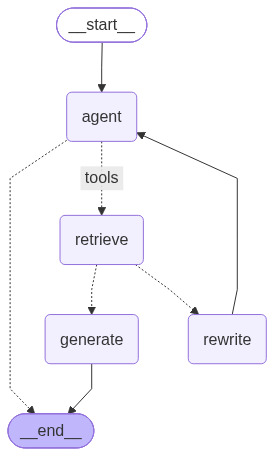

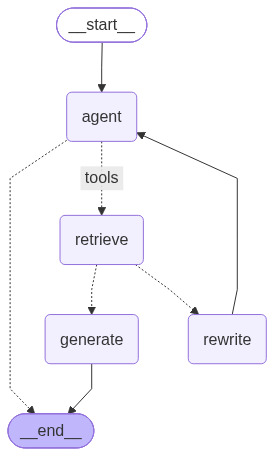

In [6]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

workflow = StateGraph(AgentState)
workflow.add_node('agent', agent)
workflow.add_node('retrieve', ToolNode(tools))
workflow.add_node('rewrite', rewrite)
workflow.add_node('generate', generate)

workflow.add_edge(START, 'agent')
workflow.add_conditional_edges(
    'agent',
    tools_condition,
    {'tools': 'retrieve', END: END},
)
workflow.add_conditional_edges(
    'retrieve',
    grade_documents,
    {'generate': 'generate', 'rewrite': 'rewrite'},
)
workflow.add_edge('generate', END)
workflow.add_edge('rewrite', 'agent')

graph = workflow.compile()
print('Decision-Maker RAG workflow compiled successfully!\n')
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
graph


## Step 6: Multi-Domain Dynamic Execution

We test the agent on questions from both domains to observe dynamic tool selection:
1. **Query 1**: *"What is Langgraph?"* $\rightarrow$ Routes to `retriever_vector_db_blog`.
2. **Query 2**: *"What is Langchain?"* $\rightarrow$ Routes to `retriever_vector_langchain_blog`.


In [7]:
# Query 1: LangGraph
print('=' * 75)
print("TEST 1: 'What is Langgraph?'")
print('=' * 75)
out1 = graph.invoke({'messages': [HumanMessage(content='What is Langgraph?')]})
print('\nFinal Answer 1:')
print(out1['messages'][-1].content)

# Query 2: LangChain
print('\n' + '=' * 75)
print("TEST 2: 'What is Langchain?'")
print('=' * 75)
out2 = graph.invoke({'messages': [HumanMessage(content='What is Langchain?')]})
print('\nFinal Answer 2:')
print(out2['messages'][-1].content)


TEST 1: 'What is Langgraph?'
--- [NODE: AGENT] Reasoning & Tool Selection ---


--- [EDGE: GRADE_DOCUMENTS] Checking relevance of retrieved docs ---


  -> DECISION: Documents IRRELEVANT -> Route to REWRITE
--- [NODE: REWRITE] Reformulating query ---


  -> Rewritten query: **Underlying intent:**  
The user wants a concise, authoritative explanation of ...
--- [NODE: AGENT] Reasoning & Tool Selection ---


--- [EDGE: GRADE_DOCUMENTS] Checking relevance of retrieved docs ---


...

  -> DECISION: Documents RELEVANT -> Route to GENERATE
--- [NODE: GENERATE] Synthesizing grounded response ---



Final Answer 1:
LangGraph is a framework for building **state‑driven, durable agent workflows**. It lets you compose, persist, and resume complex multi‑step chains (including sub‑agents), supports human‑in‑the‑loop interactions, routing, retries, and other guardrails, and provides robust execution tracking. LangChain’s agents are built on top of LangGraph to take advantage of these capabilities.

TEST 2: 'What is Langchain?'
--- [NODE: AGENT] Reasoning & Tool Selection ---


--- [EDGE: GRADE_DOCUMENTS] Checking relevance of retrieved docs ---


  -> DECISION: Documents RELEVANT -> Route to GENERATE
--- [NODE: GENERATE] Synthesizing grounded response ---



Final Answer 2:
LangChain is a Python‑centric framework for building applications that harness large language models (LLMs). It supplies a set of reusable components—such as **agents**, **models**, **memory**, **tools**, **messaging**, **event streaming**, and **middleware**—that let developers quickly assemble, run, and monitor sophisticated LLM‑driven workflows (e.g., retrieval‑augmented generation, multi‑agent coordination, and long‑term memory). By integrating with services like OpenAI, vector stores, and LangSmith for tracing and evaluation, LangChain streamlines the creation, deployment, and observability of LLM‑powered agents and applications.


## Summary

| Feature | Decision-Maker RAG | Standard RAG |
|---|---|---|
| **Tool Selection** | Dynamic across multiple specialized vectorstores | Single hardcoded retriever |
| **Document Grading** | LLM-as-a-Judge binary relevance scoring | None (all chunks fed to prompt) |
| **Self-Correction** | Automatic query rewriting loop if docs irrelevant | Static single-shot failure |
| **Conversational Fallback**| Direct response for greetings without retrieval | Always performs retrieval |
